In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

results_dir = Path("../data/processed/new_diff")


# ============================================================
# LOAD PyDESeq2 RESULTS
# ============================================================

classical = pd.read_csv(
    results_dir / "CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv"
)

proneural = pd.read_csv(
    results_dir / "CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv"
)

mesenchymal = pd.read_csv(
    results_dir / "CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv"
)


# ============================================================
# PREPARE RESULTS FOR VOLCANO PLOT
# ============================================================

def prepare_volcano(results):

    df = results.copy()

    # Remove genes without usable statistics
    df = df.dropna(
        subset=["log2FC", "FDR"]
    )

    # Avoid -log10(0)
    df["FDR"] = df["FDR"].clip(
        lower=np.finfo(float).tiny
    )

    df["-log(adjustedp)"] = (
        -np.log10(df["FDR"])
    )

    # Categories
    df["category"] = "Not Significant"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] > 1),
        "category"
    ] = "Up"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] < -1),
        "category"
    ] = "Down"

    return df


# ============================================================
# PREPARE ALL THREE
# ============================================================

classical_plot = prepare_volcano(classical).set_index("gene_name")

proneural_plot = prepare_volcano(proneural).set_index("gene_name")
mesenchymal_plot = prepare_volcano(mesenchymal).set_index("gene_name")


classical_plot.to_csv("../data/processed/new_diff/CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv")
proneural_plot.to_csv("../data/processed/new_diff/CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv")
mesenchymal_plot.to_csv("../data/processed/new_diff/CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv")

In [39]:
# ============================================================
# COUNT SIGNIFICANT GENES
# ============================================================

def count_significant_genes(df, name):

    total = (
        df["FDR"] < 0.05
    ).sum()

    up = (
        (df["FDR"] < 0.05)
        & (df["log2FC"] > 1)
    ).sum()

    down = (
        (df["FDR"] < 0.05)
        & (df["log2FC"] < -1)
    ).sum()

    print(f"\n{name}")
    print("-" * 40)
    print(f"Significant genes (FDR < 0.05): {total}")
    print(f"Upregulated (FDR < 0.05, log2FC > 1): {up}")
    print(f"Downregulated (FDR < 0.05, log2FC < -1): {down}")

    return total, up, down


# ============================================================
# RUN FOR ALL SUBTYPES
# ============================================================

classical_counts = count_significant_genes(
    classical,
    "Classical vs GTEx"
)

proneural_counts = count_significant_genes(
    proneural,
    "Proneural vs GTEx"
)

mesenchymal_counts = count_significant_genes(
    mesenchymal,
    "Mesenchymal vs GTEx"
)


Classical vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 32067
Upregulated (FDR < 0.05, log2FC > 1): 20328
Downregulated (FDR < 0.05, log2FC < -1): 6949

Proneural vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 31930
Upregulated (FDR < 0.05, log2FC > 1): 21531
Downregulated (FDR < 0.05, log2FC < -1): 6012

Mesenchymal vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 32282
Upregulated (FDR < 0.05, log2FC > 1): 20966
Downregulated (FDR < 0.05, log2FC < -1): 6793


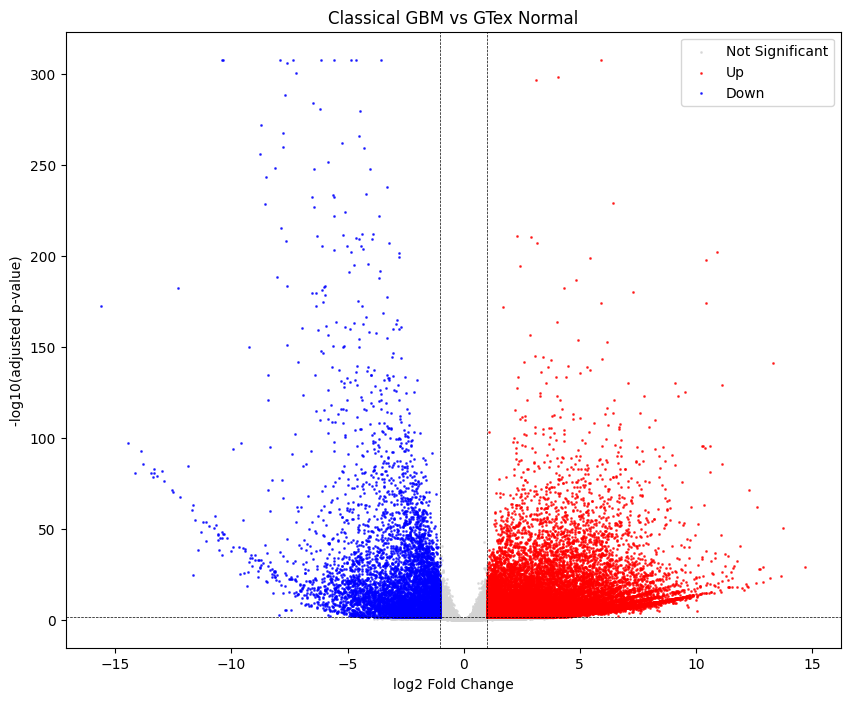

In [42]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

diff.volcano_plot(classical_plot,"Classical GBM vs GTex Normal")

In [7]:
# ============================================================
# AVERAGE VARIANCE WITHIN UPREGULATED AND DOWNREGULATED GROUPS
# ============================================================


def calculate_group_variance(results, name):
    """Calculate group means and average squared deviations."""
    groups = results[results["category"].isin(["Up", "Down"])].copy()

    summary = (
        groups.groupby("category")
        .agg(
            n_genes=("log2FC", "size"),
            mean_log2FC=("log2FC", "mean"),
            variance_log2FC=("log2FC", lambda values: values.var(ddof=0)),
            mean_neg_log10_FDR=("-log(adjustedp)", "mean"),
            variance_neg_log10_FDR=(
                "-log(adjustedp)",
                lambda values: values.var(ddof=0),
            ),
        )
        .reindex(["Up", "Down"])
    )

    summary.insert(0, "comparison", name)
    return summary.reset_index(names="regulation")


variance_summary = pd.concat(
    [
        calculate_group_variance(classical_plot, "Classical vs GTEx"),
        calculate_group_variance(proneural_plot, "Proneural vs GTEx"),
        calculate_group_variance(mesenchymal_plot, "Mesenchymal vs GTEx"),
    ],
    ignore_index=True,
)

variance_summary

,regulation,comparison,n_genes,mean_log2FC,variance_log2FC,mean_neg_log10_FDR,variance_neg_log10_FDR
0,Up,Classical vs GTEx,20328,3.976210,3.959162,12.164660,257.346107
1,Down,Classical vs GTEx,6949,-2.709618,2.763147,22.225037,1052.443925
2,Up,Proneural vs GTEx,21531,3.939814,3.733030,9.625633,144.500769
3,Down,Proneural vs GTEx,6012,-2.521920,2.630259,18.271279,812.495003
4,Up,Mesenchymal vs GTEx,20966,3.917758,3.734956,10.910001,198.602809
5,Down,Mesenchymal vs GTEx,6793,-2.821181,3.284331,21.082896,1048.375214


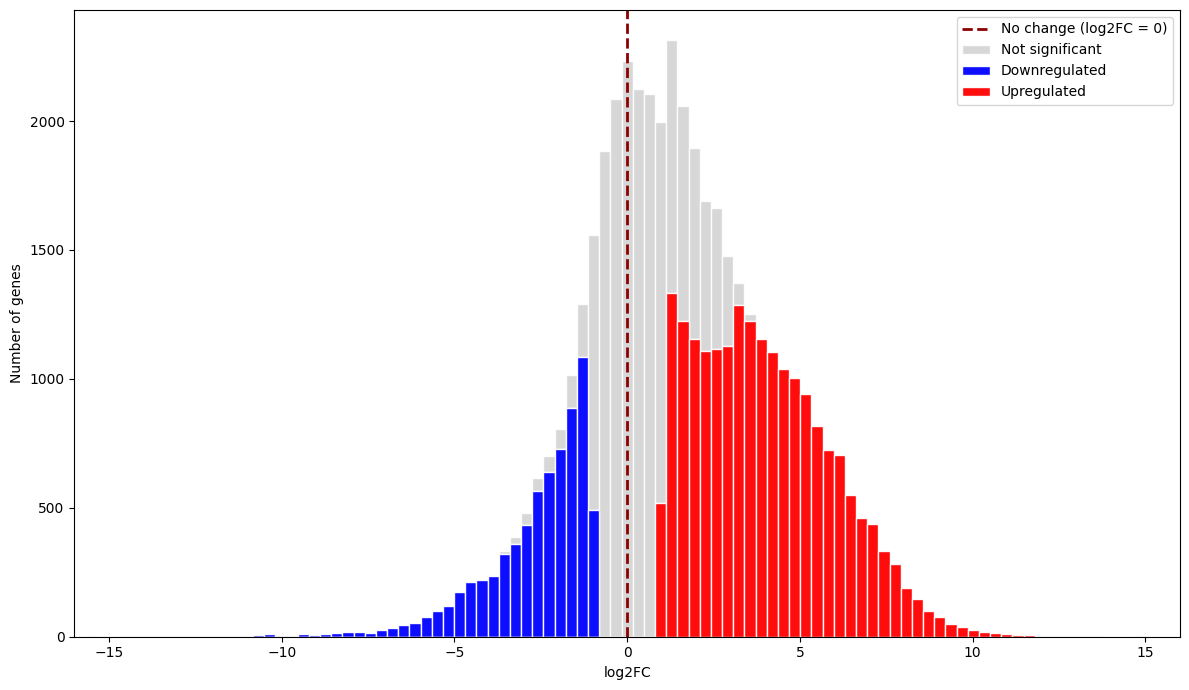

In [37]:
# ============================================================
# CLASSICAL LOG2FC DISTRIBUTION CENTERED ON ZERO
# ============================================================

upregulated_log2fc = classical_plot.loc[
    classical_plot["category"] == "Up", "log2FC"
].dropna()
downregulated_log2fc = classical_plot.loc[
    classical_plot["category"] == "Down", "log2FC"
].dropna()
not_significant_log2fc = classical_plot.loc[
    classical_plot["category"] == "Not Significant", "log2FC"
].dropna()

all_log2fc = pd.concat(
    [upregulated_log2fc, downregulated_log2fc, not_significant_log2fc]
)
plot_limit = np.ceil(np.abs(all_log2fc).max())
bins = np.linspace(-plot_limit, plot_limit, 100)
bar_left = bins[:-1]
bar_width = np.diff(bins)

total_counts, _ = np.histogram(all_log2fc, bins=bins)
down_counts, _ = np.histogram(downregulated_log2fc, bins=bins)
up_counts, _ = np.histogram(upregulated_log2fc, bins=bins)
significant_counts = down_counts + up_counts
not_significant_counts = total_counts - significant_counts

overall_mean = all_log2fc.mean()
upregulated_mean = upregulated_log2fc.mean()
downregulated_mean = downregulated_log2fc.mean()
upregulated_std = upregulated_log2fc.std(ddof=0)
downregulated_std = downregulated_log2fc.std(ddof=0)

plt.figure(figsize=(12, 7))
plt.bar(
    bar_left,
    not_significant_counts,
    bottom=significant_counts,
    width=bar_width,
    align="edge",
    color="lightgray",
    edgecolor="white",
    alpha=0.9,
    label="Not significant",
)
plt.bar(
    bar_left,
    down_counts,
    bottom=0,
    width=bar_width,
    align="edge",
    color="blue",
    edgecolor="white",
    alpha=0.95,
    label=(
        f"Downregulated"
    ),
)
plt.bar(
    bar_left,
    up_counts,
    bottom=0,
    width=bar_width,
    align="edge",
    color="red",
    edgecolor="white",
    alpha=0.95,
    label=(
        f"Upregulated"

    ),
)
plt.axvline(
    0,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="No change (log2FC = 0)",
)

plt.xlim(-plot_limit, plot_limit)
plt.xlabel("log2FC")
plt.ylabel("Number of genes")
plt.legend()
plt.tight_layout()
plt.show()

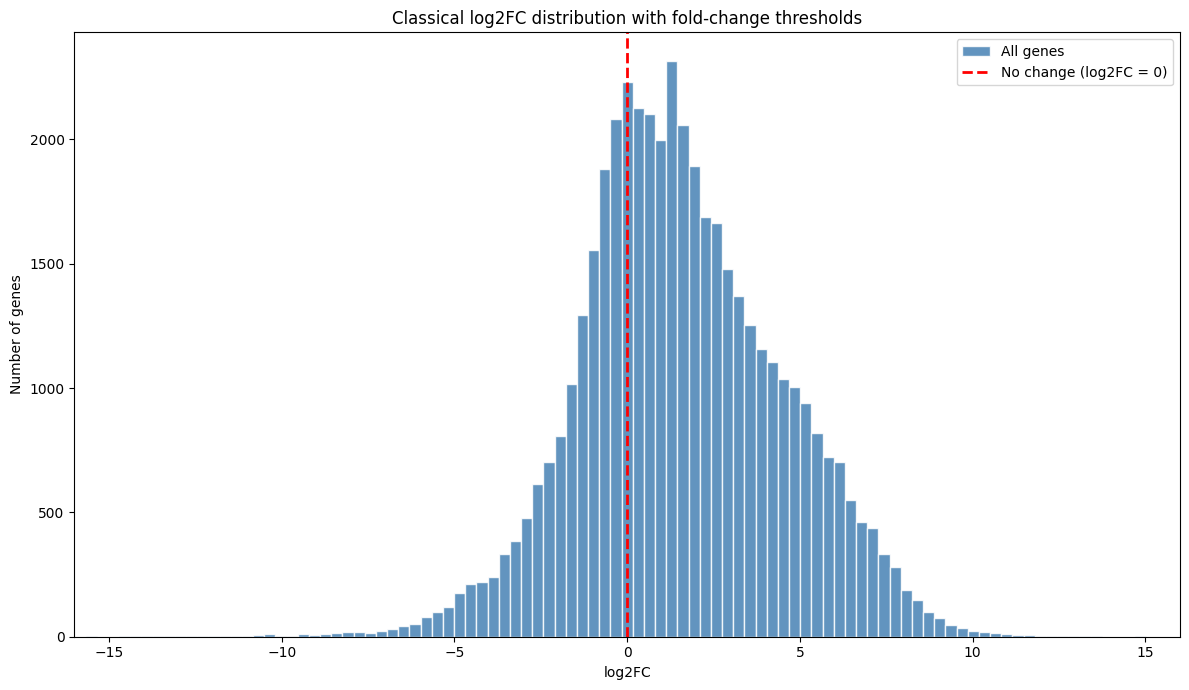

In [36]:
# ============================================================
# CLASSICAL LOG2FC DISTRIBUTION WITHOUT GROUP COLORING
# ============================================================

all_classical_log2fc = classical_plot["log2FC"].dropna()
plot_limit = np.ceil(np.abs(all_classical_log2fc).max())
bins = np.linspace(-plot_limit, plot_limit, 100)

plt.figure(figsize=(12, 7))
plt.hist(
    all_classical_log2fc,
    bins=bins,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
    label="All genes",
)
plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="No change (log2FC = 0)",
)

plt.xlim(-plot_limit, plot_limit)
plt.xlabel("log2FC")
plt.ylabel("Number of genes")
plt.title("Classical log2FC distribution with fold-change thresholds")
plt.legend()
plt.tight_layout()
plt.show()